# Notebook 08 — Carbon nanotubes: the system-level gap (F8, T7)

The question a materials paper's weight percent cannot answer: what would this
uptake become in a complete tank? And a question this project can ask that the
materials literature cannot, because it needs a system model: is the reported
value physically consistent at all?

Every CNT value used here was read from the primary paper, not from a review,
and `data/materials/cnt_literature.yaml` carries the verbatim sentence and page
for each. All seven papers come from the HyCAN-DB corpus, which is the interlock
this project was designed around: the database supplies the measurements and
this model supplies their consequence.

**Claim C4 is reported in RELATIVE form, and the reason matters.** This model
puts AX-21 activated carbon above the DOE 2025 gravimetric target at the
baseline envelope, which it does not achieve in reality. That is the Gate V3 gap
showing, and it means no claim of the form "CNTs fall short of the target by a
factor of X" is defensible here. A ratio against AX-21 at the same envelope
cancels a bias in the shared denominator, so the ordering survives where the
levels do not.

In [1]:
%matplotlib inline

from pathlib import Path

import yaml

from h2star import envelope, inverse, isotherm, system, uq
from h2star.viz import plot_cnt_gap

In [2]:
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data").is_dir():
    REPO_ROOT = Path("..").resolve()

material = isotherm.Material.from_yaml(REPO_ROOT / "data" / "materials" / "ax21.yaml")
da = isotherm.ModifiedDA(material)
engineering = system.EngineeringParams.from_yaml(REPO_ROOT / "data" / "engineering.yaml")
targets = inverse.load_doe_targets(
    REPO_ROOT / "data" / "targets" / "doe_targets.yaml", "2025")
spec = uq.UncertaintySpec.from_yaml(REPO_ROOT / "data" / "uncertainty.yaml")

print(f"material : {material.name}")
print(f"targets  : {targets.label} - GC >= {targets.gc} kg/kg, VC >= {targets.vc} kg/L")
print(f"UQ layers: material {spec.material.parameters} + scalars {spec.scalar_names}")

material : AX-21
targets  : DOE 2025 - GC >= 0.055 kg/kg, VC >= 0.04 kg/L
UQ layers: material ('n_max', 'alpha', 'v_a') + scalars ('sigma_allow', 'mli_k_eff', 'heat_leak_budget', 'bop_fixed', 'rho_bulk')


In [3]:
with open(REPO_ROOT / "data" / "materials" / "cnt_literature.yaml") as fh:
    corpus = yaml.safe_load(fh)

print(f"{len(corpus['entries'])} entries, all read from primary sources\n")
print(f"{'entry':14s} {'wt%':>7s} {'T (K)':>7s} {'P (MPa)':>8s} {'basis':>12s}")
for entry in corpus["entries"]:
    u = entry["uptake"]
    print(f"{entry['key']:14s} {u['value']:7.3f} {u['temperature_K']:7.1f} "
          f"{u['pressure_MPa']:8.3f} {u['basis']:>12s}")
print()
print("What the corpus does NOT record, which bounds everything below:")
print(f"  papers stating excess vs absolute basis: "
      f"{sum(1 for e in corpus['entries'] if e['uptake']['basis'] != 'not_stated')}"
      f" of {len(corpus['entries'])}")
print(f"  papers reporting a bulk density         : "
      f"{sum(1 for e in corpus['entries'] if e['bulk_density_stated'])}"
      f" of {len(corpus['entries'])}")
print(f"  papers printing a DOI                   : "
      f"{sum(1 for e in corpus['entries'] if e['doi'])}"
      f" of {len(corpus['entries'])}")

7 entries, all read from primary sources

entry              wt%   T (K)  P (MPa)        basis
liu1999          4.200   298.0   10.000   not_stated
chen1999        20.000   653.0    0.101   not_stated
qikun2002        8.000   298.0    0.140   not_stated
zhou2004         0.175   233.0    6.000   not_stated
tibbetts2001     0.050   296.0    3.590   not_stated
takagi2004       1.800    77.0    0.100   not_stated
liu2010          1.700   292.1   12.200   not_stated

What the corpus does NOT record, which bounds everything below:
  papers stating excess vs absolute basis: 0 of 7
  papers reporting a bulk density         : 1 of 7
  papers printing a DOI                   : 5 of 7


## The weight-percent convention, settled from a source rather than assumed

"x weight percent hydrogen" may mean hydrogen over total mass or hydrogen over
sorbent mass. The two differ by about 4% at 4 wt% and 25% at 20 wt%.

Liu 1999 happens to report both a weight percent and a hydrogen-to-carbon atom
ratio, which decides the question for that paper without us having to choose.

In [4]:
for convention in inverse.WT_PERCENT_CONVENTIONS:
    ratio = inverse.hydrogen_to_carbon_ratio(4.2, convention)
    print(f"  4.2 wt% on the {convention:11s} basis -> H/C = {ratio:.4f}")
print()
print('Liu 1999 states: "4.2 weight percent, or a hydrogen to carbon atom '
      'ratio of 0.52"')
print("-> the paper is on the total-mass basis, which is the default used here.")

  4.2 wt% on the of_total    basis -> H/C = 0.5224
  4.2 wt% on the of_sorbent  basis -> H/C = 0.5005

Liu 1999 states: "4.2 weight percent, or a hydrogen to carbon atom ratio of 0.52"
-> the paper is on the total-mass basis, which is the default used here.


## The inference chain, and what it assumes

The literature reports one uptake at one temperature and pressure. The system
model needs a full parameter vector. Bridging that gap means keeping AX-21's
characteristic energy, pseudo-saturation pressure, adsorbed-phase volume and
densities, and solving only for the limiting uptake that reproduces the reported
point.

Four assumptions, named because they are the reason the uncertainty is large:
the D-A form is assumed to describe a nanotube; `alpha`, `beta` and `p0`
transfer from an activated carbon; `v_a` and both densities transfer too, and no
CNT paper in the corpus reports a packing density at all; and the measurement
basis is assumed, because no paper states it.

That last one is not a small ambiguity.

In [5]:
primary = next(e for e in corpus["entries"]
               if e["key"] == corpus["case_study"]["primary_entry"])
absolute = inverse.material_from_corpus_entry(material, primary, "absolute").n_max
excess = inverse.material_from_corpus_entry(material, primary, "excess").n_max
print(f"{primary['key']}: reported {primary['uptake']['value']} wt%")
print(f"  on an absolute basis -> n_max = {absolute:.2f} mol/kg")
print(f"  on an excess basis   -> n_max = {excess:.2f} mol/kg")
print(f"  ambiguity factor     = {excess/absolute:.2f}x, "
      f"from a distinction no paper states")

liu2010: reported 1.7 wt%
  on an absolute basis -> n_max = 53.53 mol/kg
  on an excess basis   -> n_max = 95.22 mol/kg
  ambiguity factor     = 1.78x, from a distinction no paper states


## The physical-consistency screen

The pore-volume constraint was established in the Gate V4 record, before any
CNT value was read: the adsorbed phase has to fit inside the volume the packing
leaves. Applied to reported uptakes it becomes a screen, and the screen has an
opinion about two of them.

In [6]:
limit_fit = inverse.coherent_n_max_limit(
    material, inverse.fit_va_slope(spec.material))
limit_physical = inverse.coherent_n_max_limit(
    material, inverse.V_LIQUID_H2_MOLAR)
print(f"pore volume exhausted at n_max = {limit_fit:.1f} mol/kg "
      f"(fit correlation)")
print(f"pore volume exhausted at n_max = {limit_physical:.1f} mol/kg "
      f"(A-ISO-4)")
print(f"AX-21 reference                = {material.n_max:.1f} mol/kg")
print()

screen_rows = []
for entry in corpus["entries"]:
    if entry["key"] == "chen1999":
        print(f"{entry['key']:14s} EXCLUDED: chemisorption on the paper's "
              f"own analysis")
        continue
    try:
        n_max = inverse.material_from_corpus_entry(
            material, entry, "absolute").n_max
        accepted = n_max <= limit_physical
        note = "" if accepted else "exceeds the pore-volume limit"
    except ValueError:
        n_max, accepted = None, False
        note = "no $n_{max}$ reproduces the reported point"
    screen_rows.append((entry["key"], n_max, accepted, note))
    shown = f"{n_max:8.2f}" if n_max is not None else "    none"
    print(f"{entry['key']:14s} n_max {shown}   "
          f"{'ACCEPTED' if accepted else 'REJECTED'}  {note}")

pore volume exhausted at n_max = 104.9 mol/kg (fit correlation)
pore volume exhausted at n_max = 124.1 mol/kg (A-ISO-4)
AX-21 reference                = 71.6 mol/kg

liu1999        n_max   163.00   REJECTED  exceeds the pore-volume limit
chen1999       EXCLUDED: chemisorption on the paper's own analysis
qikun2002      n_max     none   REJECTED  no $n_{max}$ reproduces the reported point
zhou2004       n_max     6.61   ACCEPTED  
tibbetts2001   n_max     4.57   ACCEPTED  
takagi2004     n_max    56.95   ACCEPTED  
liu2010        n_max    53.53   ACCEPTED  


Two rejections, and they are the two values the experimental literature
contests.

Liu 1999's 4.2 wt% is the field's most-cited CNT claim. It implies a limiting
uptake beyond both pore-volume limits: a material whose adsorbed phase would
exceed its own pore volume. Wang Qikun's 8.0 wt% is worse, in that no limiting
uptake reproduces the reported point at all.

Neither rejection uses any of the experimental evidence raised against those
values at the time. Tibbetts et al. (2001) questioned Liu 1999 on calibration
and thermal-equilibrium grounds, and Liu et al. (2010) — the same senior author
and the same laboratory — wrote that "our previous reported hydrogen storage
capacities were overestimated". All three papers are in this corpus, so the
provenance chain closes inside the dataset, and this model reaches the same
verdict from a pore-volume argument that uses none of it.

The four entries the screen accepts are the four with reversible isotherms and
hydride-calibrated apparatus. The screen was not tuned to produce that
alignment.

## Table T7 — the gap, entry by entry

Relative to AX-21, for the reason given at the top: the absolute levels inherit
the Gate V3 gap, the ratios do not.

In [7]:
baseline = envelope.OperatingPoint(P_full=100.0e5, T_full=80.0)
reference = envelope.evaluate_envelope(
    material, da, engineering, *baseline.as_tuple())
print(f"AX-21 at this envelope: GC {reference['GC']:.5f} kg/kg, "
      f"VC {reference['VC']:.5f} kg/L")
print(f"DOE 2025 target        : GC {targets.gc} kg/kg, "
      f"VC {targets.vc} kg/L")
print("-> this model puts AX-21 ABOVE the gravimetric target, which it does "
      "not achieve in reality.")
print("   The HSECoE full-state figure is 0.0312 kg/kg. That is the Gate V3 "
      "gap, and it is why")
print("   the column that matters below is the ratio, not the level.\n")

print(f"{'entry':14s} {'n_max':>8s} {'GC':>9s} {'VC':>9s} {'vs AX-21':>9s}")
for key, n_max, accepted, _ in screen_rows:
    if not accepted:
        print(f"{key:14s} {'-':>8s} {'rejected by the screen':>30s}")
        continue
    entry = next(e for e in corpus["entries"] if e["key"] == key)
    candidate = inverse.material_from_corpus_entry(
        material, entry, "absolute")
    budget = envelope.evaluate_envelope(
        candidate, isotherm.ModifiedDA(candidate), engineering,
        *baseline.as_tuple())
    print(f"{key:14s} {n_max:8.2f} {budget['GC']:9.5f} {budget['VC']:9.5f} "
          f"{budget['GC']/reference['GC']:8.2f}x")

AX-21 at this envelope: GC 0.06522 kg/kg, VC 0.02601 kg/L
DOE 2025 target        : GC 0.055 kg/kg, VC 0.04 kg/L
-> this model puts AX-21 ABOVE the gravimetric target, which it does not achieve in reality.
   The HSECoE full-state figure is 0.0312 kg/kg. That is the Gate V3 gap, and it is why
   the column that matters below is the ratio, not the level.

entry             n_max        GC        VC  vs AX-21
liu1999               -         rejected by the screen
qikun2002             -         rejected by the screen
zhou2004           6.61   0.03199   0.00982     0.49x
tibbetts2001       4.57   0.03073   0.00934     0.47x
takagi2004        56.95   0.05870   0.02227     0.90x
liu2010           53.53   0.05710   0.02141     0.88x


## The cascade, and figure F8

The waterfall takes the same usable hydrogen and divides it by a larger
denominator at each stage, so the sequence starts at the material-level number
and ends at the system gravimetric capacity with every drop attributable.

The whiskers are the excess/absolute ambiguity rather than an engineering
uncertainty, because that ambiguity is the larger of the two and it comes from
the literature rather than from the model.

In [8]:
waterfalls = {}
for basis in ("absolute", "excess"):
    candidate = inverse.material_from_corpus_entry(
        material, primary, basis)
    budget = envelope.evaluate_envelope(
        candidate, isotherm.ModifiedDA(candidate), engineering,
        *baseline.as_tuple())
    waterfalls[basis] = system.gap_waterfall(budget)

for stage, label, value, wt in waterfalls["absolute"]["stages"]:
    print(f"  {label:34s} {value:.5f} kg/kg = {wt:5.2f} wt%")
print()
print(f"total loss factor, material to system: "
      f"{waterfalls['absolute']['total_factor']:.2f}x")

  Material uptake at full state      0.10789 kg/kg =  9.74 wt%
  Usable swing only                  0.10156 kg/kg =  9.22 wt%
  + hydrogen's own mass              0.09167 kg/kg =  8.40 wt%
  + pressure vessel                  0.07201 kg/kg =  6.72 wt%
  + insulation                       0.06824 kg/kg =  6.39 wt%
  + balance of plant = system GC     0.05710 kg/kg =  5.40 wt%

total loss factor, material to system: 1.89x


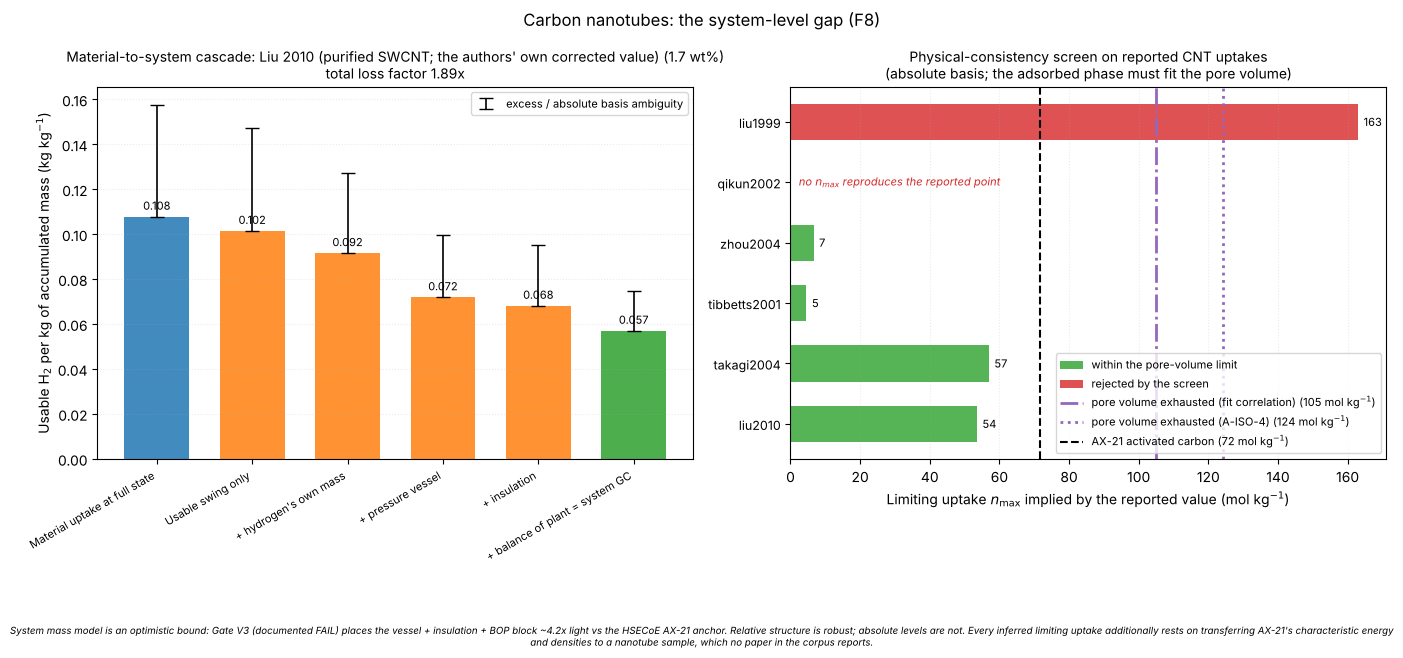

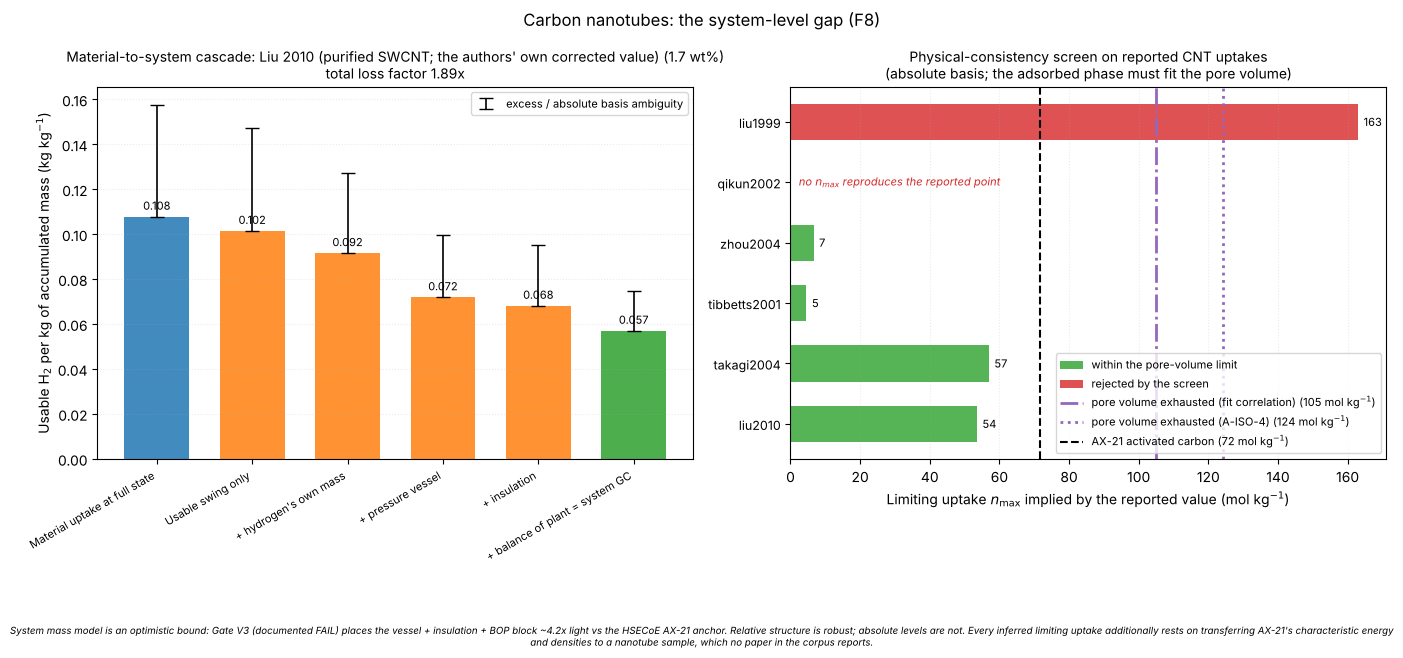

In [9]:
screen = {
    "entries": screen_rows,
    "limits": {"pore volume exhausted (fit correlation)": limit_fit,
               "pore volume exhausted (A-ISO-4)": limit_physical},
    "reference": ("AX-21 activated carbon", material.n_max),
}

fig, _ = plot_cnt_gap(
    {"label": f"{primary['label']} ({primary['uptake']['value']} wt%)",
     "primary": waterfalls["absolute"], "alternate": waterfalls["excess"]},
    screen,
    savepath=REPO_ROOT / "figures" / "F8_cnt_gap.png")
fig

## What the corpus says taken together

Across the five physisorption entries with a room-temperature value, the
reported uptake spans a factor of 160 on nominally the same class of material.
Two of those five fail a physical-consistency screen. None states its
measurement basis. One of seven reports a bulk density.

That is not a criticism of the papers, several of which are unusually careful
about their own apparatus and two of which correct the record. It is a statement
about what the literature, in aggregate, does and does not determine — and it is
the same conclusion the uncertainty analysis in notebook 07 reached from the fit
covariance, arrived at from the other direction.

The interpretation and the limits on what may be claimed are written up in
`docs/`.